In [4]:
#Python v3.10.11
#Import necessary packages

import os
import sys
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

import warnings
warnings.simplefilter(action='ignore')
import pandas as pd
import matplotlib.image as mpimg
import matplotlib as mpl

sys.path.append('functions')

from death_prediction_functions import time_to_death_grouped, cross_validation, train_nn, generate_nn_pred
from gene_analysis_functions import get_great, get_cistrome, get_pos, insig_nan

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
#set directory and get relevant files

os.chdir('/Users/samanderson/Desktop/pellegrini_lab_research/model_outputs')
death_pvals = pd.read_excel('death_classifier_probes.xlsx', index_col=0)
pinv_pvals = pd.read_excel('pseudoinverse_probes_filtered.xlsx', index_col=0)

In [6]:
#blood glucose probes
GLU_probes = pinv_pvals['M10_poststress_GLU_pval']
GLU_probes = GLU_probes.dropna()
GLU_probes = list(GLU_probes.index)

#aging probes
age_probes = death_pvals
age_probes = age_probes.dropna()
print(age_probes)

age_probes = list(age_probes.index)

intersections = list(set(GLU_probes) & set(age_probes))
cross_identified_probes = death_pvals.loc[intersections]
cross_identified_probes = cross_identified_probes[['coef', 'associated_genes']]
cross_identified_probes

                      627       629       630       633       636       637  \
ID                                                                            
cg23671739_TC21  0.320928  0.279549  0.273689  0.304919  0.332700  0.283284   
cg28117414_TC21  0.884191  0.868994  0.128778  0.848877  0.890351  0.873927   
cg28119996_TC21  0.565087  0.674023  0.856559  0.746848  0.613722  0.688759   
cg28129849_BC11  0.273244  0.248010  0.387962  0.328414  0.274609  0.390311   
cg28129849_BC12  0.301069  0.322319  0.360591  0.387231  0.299171  0.430237   
...                   ...       ...       ...       ...       ...       ...   
cg48310527_BC11  0.179715  0.322948  0.291671  0.325900  0.402866  0.321608   
cg48330215_TC21  0.175931  0.407679  0.201322  0.082243  0.331018  0.215848   
cg48343900_TC21  0.605775  0.688669  0.628135  0.477835  0.664903  0.623626   
cg48343995_TC11  0.274822  0.428012  0.223358  0.292540  0.387572  0.274029   
cg48344145_TC21  0.295866  0.353221  0.283526  0.232

,coef,associated_genes
ID,,
cg33482097_TC21,0.382163,"['Adgrb1 (-548,371), Mroh5 (-128,153)']"
cg32213071_BC21,0.288505,"['Lrrc3b (-598,299), Ngly1 (-211,994)']"
cg28117414_TC21,0.389743,"['Akap12 (-53,293), Mthfd1l (+239,956)']"
cg33480444_BC22,0.047938,"['Gm6569 (-24,652), Ptp4a3 (+84,979)']"
cg32227304_BC11,0.105626,"['Ube2e1 (-213,326), Ube2e2 (+348,591)']"
cg35891694_BC21,0.235185,"['Mbd2 (-20,881), Poli (-16,688)']"
cg35547938_BC21,0.025468,"['Pik3c3 (-3,266)']"
cg32206002_BC21,0.129534,"['Slc4a7 (-43,194), Olfr721-ps1 (+251,861)']"
cg33480444_BC21,0.083699,"['Gm6569 (-24,652), Ptp4a3 (+84,979)']"


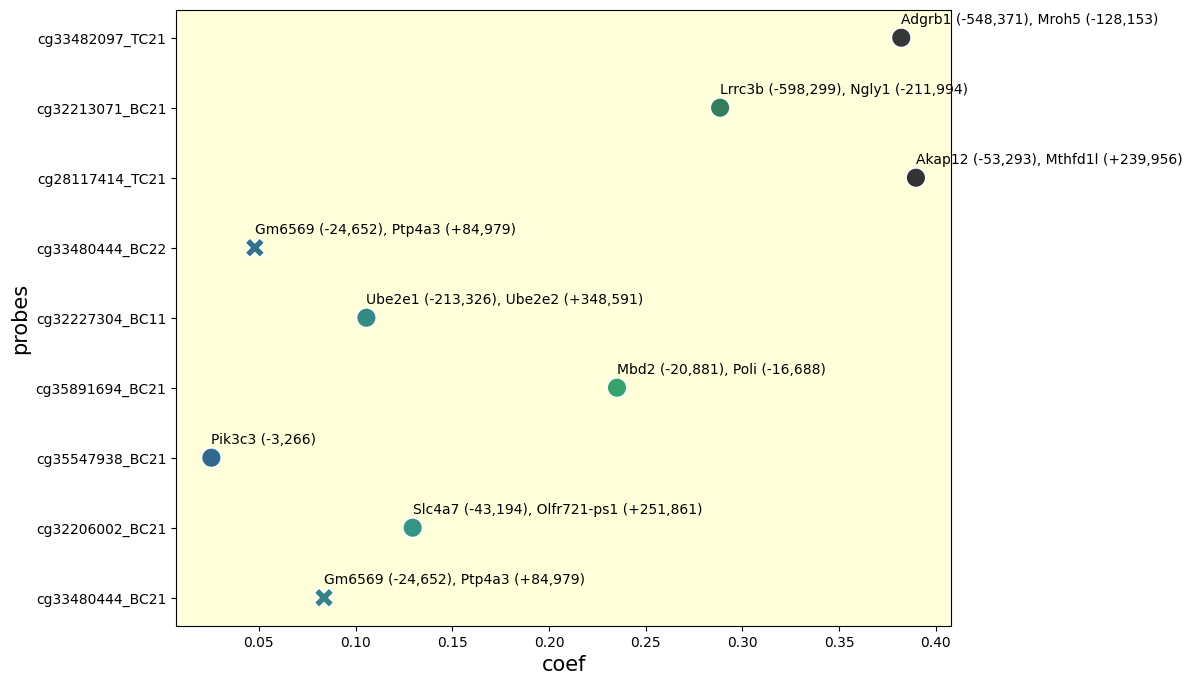

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import re

# Extract genes from associated_genes column
def extract_genes(gene_string):
    # Use regex to match gene names with or without coordinates
    gene_matches = re.findall(r'([A-Za-z0-9]+)\s*\(\+\d+,\d+\)?', gene_string)
    genes = [match for match in gene_matches]  # Extract gene names
    return genes

# Apply the function to each entry in 'associated_genes' column
associated_genes_full = [eval(gene) for gene in cross_identified_probes['associated_genes']]
cross_identified_probes['genes'] = cross_identified_probes['associated_genes'].apply(extract_genes)

# Count occurrences of each gene across all entries
gene_counts = pd.Series([gene for genes_list in cross_identified_probes['genes'] for gene in genes_list]).value_counts()

# Determine duplication status of each gene
is_duplicated = {gene: count > 1 for gene, count in gene_counts.items()}

# Define marker style based on duplication status
marker_style = ['o' if any(is_duplicated[gene] for gene in genes) else '^' for genes in cross_identified_probes['genes']]

# Create the scatterplot with emphasized duplicated genes
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=cross_identified_probes, x='coef', y='ID', hue='coef', palette='viridis_d', 
                style=marker_style, s=200, legend=False)

# Annotate each point with associated genes
for i, genes in enumerate(cross_identified_probes['genes']):
    x = cross_identified_probes['coef'][i]
    y = cross_identified_probes.index
    annot = ', '.join(genes)  # Join the list of g

for i, genes in enumerate(associated_genes_full):
    x = cross_identified_probes['coef'][i]
    y = cross_identified_probes.index[i]
    annot = ', '.join(genes)  # Join the list of genes into a string
    ax.annotate(annot, (x, y), textcoords="offset points", xytext=(0, 10), ha='left')

plt.xlabel('coef', size=15)
plt.ylabel('probes', size=15)

ax.set_facecolor((1, 1, 0.8509803921))

plt.show()